In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print(np.random.seed(42)) #  By setting the seed to 42, you ensure that the algorithm always produces the exact same sequence of numbers every time the code is run

n = 300

x = np.random.randn(n)
y = np.random.randn(n)
z = 0.6*x + 0.2*y + np.random.randn(n)
datos_3d = np.column_stack((x,y,z))

None


In [27]:
def pca_desde_cero(X,n_componentes):

  # Paso 1: Estandarizar los datos
  X_centrado = X - np.mean(X, axis = 0)
  X_estandarizado = X_centrado / np.std(X, axis = 0)

  # Paso 2: Calcular la matriz de covarianza
  cov_matriz = np.cov(X_estandarizado, rowvar = False)

  # Paso 3: Calculas los eigenvectors and eigenvalues

  #eigenvalues, eigenvectors = np.linalg.eigh(cov_matriz) # np.linalg.eig or np.linalg.eigh (Hermitian or Real Symmetric matrices)
  eigenvalues, eigenvectors = np.linalg.eig(cov_matriz) # np.linalg.eig or np.linalg.eigh (Hermitian or Real Symmetric matrices)

  ind_ordenados = np.argsort(eigenvalues)[::-1]
  eigenvectors_sort = eigenvectors[:, ind_ordenados]

  # Paso 4: Proyectar los Datos

  componentes_principales = eigenvectors_sort[:, :n_componentes]
  datos_proyectados = np.dot(X_estandarizado, componentes_principales)

  return datos_proyectados

datos_pca_proyectados = pca_desde_cero(datos_3d, 2)


In [34]:
scaler = StandardScaler()
datos_estandarizados = scaler.fit_transform(datos_3d)
pca_sklearn = PCA(n_components = 2)
datos_pca_sklearn = pca_sklearn.fit_transform(datos_estandarizados)

In [35]:
print(f"resultados de nuestro PCA:\n {np.round(datos_pca_proyectados[:5],2)}")
print(f"resultados de sklearn PCA:\n {np.round(datos_pca_sklearn[:5],2)}")

resultados de nuestro PCA:
 [[ 0.76 -0.89]
 [-0.9  -0.59]
 [ 1.38  0.7 ]
 [ 2.6   0.41]
 [-0.04  0.07]]
resultados de sklearn PCA:
 [[ 0.76 -0.89]
 [-0.9  -0.59]
 [ 1.38  0.7 ]
 [ 2.6   0.41]
 [-0.04  0.07]]


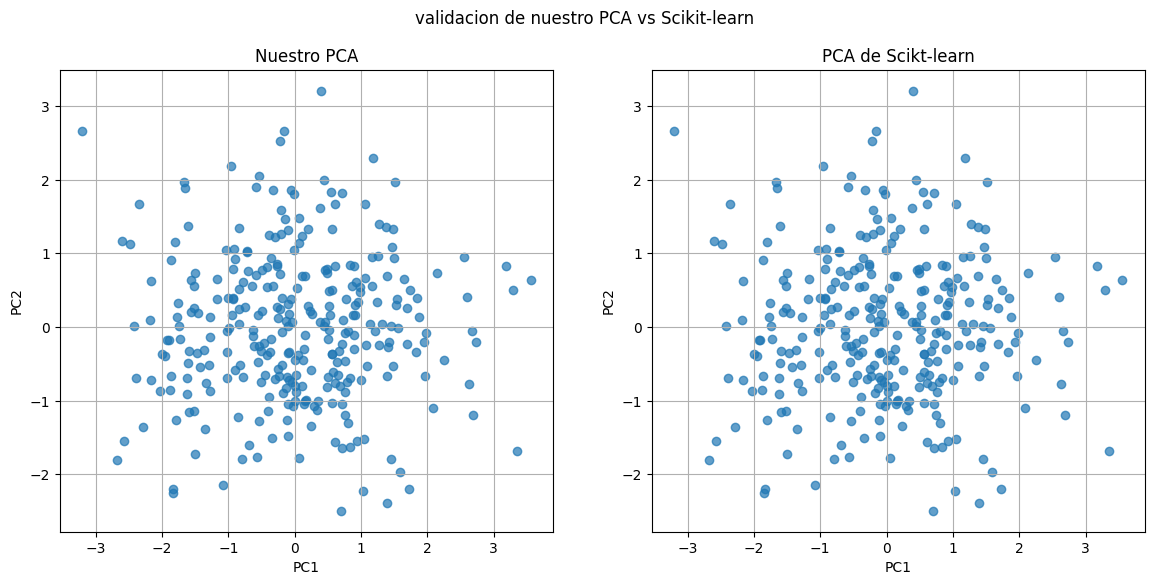

In [36]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (14,6))
ax1.scatter(datos_pca_proyectados[:,0], datos_pca_proyectados[:,1], alpha = 0.7)
ax1.set_title("Nuestro PCA")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.grid(True)

ax2.scatter(datos_pca_sklearn[:,0], datos_pca_sklearn[:,1], alpha = 0.7)
ax2.set_title("PCA de Scikt-learn")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.grid(True)

plt.suptitle("validacion de nuestro PCA vs Scikit-learn")
plt.show()

